# ML Pipeline - CFPB Consumer Complaints Classification

**Dataset:** [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/#get-the-data)  
**Task:** Phân loại khiếu nại người tiêu dùng theo danh mục sản phẩm tài chính  
**Approach:** Traditional ML pipeline (BoW, TF-IDF, n-gram) + Deep learning embeddings (Word2Vec, BERT)

---

**Cấu trúc notebook:**

1. Setup & Cài thư viện
2. Tải và sampling dữ liệu
3. EDA (Exploratory Data Analysis)
4. Tiền xử lý văn bản
5. Trích xuất đặc trưng truyền thống (BoW, TF-IDF, n-gram)
6. Trích xuất đặc trưng hiện đại (Word2Vec, BERT)
7. Huấn luyện và đánh giá mô hình
8. Hyperparameter Tuning
9. So sánh kết quả & kết luận


## 1. Setup & Cài thư viện


In [4]:
# Clone repo về Colab (bỏ qua nếu đang chạy local)
import sys

if "google.colab" in sys.modules:
    import subprocess
    result = subprocess.run(
        ["git", "clone", "https://github.com/bawfng04/ml-text-pipeline-cfpb.git"],
        capture_output=True, text=True
    )
    print(result.stdout or result.stderr)
    %cd ml-text-pipeline-cfpb
else:
    print("Running locally - skipping git clone.")

Cloning into 'ml-text-pipeline-cfpb'...

/content/ml-text-pipeline-cfpb


In [5]:
# Cài thư viện bổ sung không có sẵn trên Colab
# (sentence-transformers, gensim, wordcloud cần install thêm)
import subprocess, sys


def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])


pip_install(
    "sentence-transformers>=2.6.0",
    "gensim>=4.3.0",
    "wordcloud>=1.9.0",
    "pyarrow>=12.0.0",  # cần cho to_parquet / read_parquet
)
print("Done.")

Done.


In [6]:
import os, sys, gc, pickle, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.sparse as sp

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110

# Detect môi trường một lần duy nhất ở đây (dùng lại ở nhiều cells)
IN_COLAB = "google.colab" in sys.modules

REPO_ROOT = Path(".").resolve()
sys.path.insert(0, str(REPO_ROOT))

DATA_DIR = REPO_ROOT / "data"
FEATURES_DIR = REPO_ROOT / "features"
REPORTS_DIR = REPO_ROOT / "reports"

DATA_DIR.mkdir(exist_ok=True)
FEATURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

import nltk
from modules.text_preprocessor import download_nltk_resources

download_nltk_resources()

print(f"Root      : {REPO_ROOT}")
print(f"Python    : {sys.version.split()[0]}")
print(f"In Colab  : {IN_COLAB}")

Root      : /content/ml-text-pipeline-cfpb
Python    : 3.12.12
In Colab  : True


## 2. Tải và Sampling Dữ liệu

Dataset gốc ~7.8GB, ~13.7M rows, chỉ 27% có `Consumer complaint narrative`.

**Chiến lược sampling:**

- Đọc chunked (200k rows/lần) để không load toàn bộ vào RAM
- Gộp các tên product bị đổi tên theo thời gian về nhãn thống nhất
- Drop class có < 1,000 samples (không đủ để train có ý nghĩa)
- Chỉ giữ **top 7 classes** nhiều samples nhất → đủ đa dạng, tránh BERT chạy quá lâu
- Stratified sample **2,000 mẫu/class** → tổng **~14,000 rows**

**Lý do 7 × 2k thay vì ít hơn:**  
Assignment yêu cầu "đa dạng về nội dung / nhiều nhãn phân loại" — 7 classes đủ để confusion matrix có ý nghĩa và phân tích per-class F1 có chiều sâu. BERT encode 14k samples trên Colab CPU mất ~8–10 phút, vẫn trong giới hạn an toàn.


In [7]:
import urllib.request, zipfile

DATA_URL = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"
ZIP_PATH = DATA_DIR / "complaints.csv.zip"
CSV_PATH = DATA_DIR / "complaints.csv"

DATA_DIR.mkdir(exist_ok=True)

if not CSV_PATH.exists():
    print("Downloading dataset (~1GB compressed)...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    size_gb = CSV_PATH.stat().st_size / 1e9
    print(f"Dataset found: {CSV_PATH} ({size_gb:.1f} GB)")

Extracting...
Done.


In [8]:
# ── CẤU HÌNH PIPELINE ──────────────────────────────────────────────
TOP_N_CLASSES = 7  # giữ N class có nhiều samples nhất
SAMPLES_PER_CLASS = 2_000  # tổng ~14k rows (7 x 2000)
MIN_CLASS_SIZE = 1_000  # drop class có ít narrative hơn ngưỡng này
RANDOM_STATE = 42
# ────────────────────────────────────────────────────────────────────
# Lý do chọn 7 classes x 2k:
#   - Đủ đa dạng theo yêu cầu (nhiều nhãn phân loại khác nhau)
#   - 14k samples: BERT CPU encode ~8-10 phút trên Colab
#   - 2000/class đủ để LR/SVM/NB hội tụ tốt
# ────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "Credit reporting, credit repair services, or other personal consumer reports": "Credit reporting",
    "Credit reporting or other personal consumer reports": "Credit reporting",
    "Credit reporting": "Credit reporting",
    "Debt collection": "Debt collection",
    "Mortgage": "Mortgage",
    "Credit card": "Credit card",
    "Credit card or prepaid card": "Credit card",
    "Checking or savings account": "Bank account",
    "Bank account or service": "Bank account",
    "Student loan": "Student loan",
    "Vehicle loan or lease": "Vehicle loan",
    "Consumer Loan": "Vehicle loan",
    "Money transfer, virtual currency, or money service": "Money transfer",
    "Money transfers": "Money transfer",
    "Payday loan, title loan, or personal loan": "Payday loan",
    "Payday loan, title loan, personal loan, or advance loan": "Payday loan",
    "Payday loan": "Payday loan",
}

COLS = ["Product", "Consumer complaint narrative", "Date received"]
chunks = []

print("Reading dataset (chunked)...")
for chunk in pd.read_csv(CSV_PATH, usecols=COLS, chunksize=200_000, low_memory=False):
    mask = chunk["Consumer complaint narrative"].notna() & (
        chunk["Consumer complaint narrative"].str.strip().str.len() > 50
    )
    chunk = chunk[mask].copy()
    chunk["label"] = chunk["Product"].map(LABEL_MAP)
    chunk = chunk.dropna(subset=["label"])
    chunks.append(chunk[["Consumer complaint narrative", "label", "Date received"]])

df_full = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

# Bước 1: Drop class có quá ít narrative
class_counts = df_full["label"].value_counts()
valid_classes = class_counts[class_counts >= MIN_CLASS_SIZE].index
dropped_small = class_counts[class_counts < MIN_CLASS_SIZE]
if len(dropped_small):
    print(f"Dropped (< {MIN_CLASS_SIZE} samples): {dropped_small.to_dict()}")
df_full = df_full[df_full["label"].isin(valid_classes)]

# Bước 2: Giữ top N classes nhiều samples nhất
# Đảm bảo đa dạng nhưng không quá nhiều class làm pipeline nặng
top_classes = df_full["label"].value_counts().head(TOP_N_CLASSES).index.tolist()
dropped_tail = [c for c in valid_classes if c not in top_classes]
if dropped_tail:
    print(f"Kept top {TOP_N_CLASSES} classes. Dropped: {dropped_tail}")
df_full = df_full[df_full["label"].isin(top_classes)]

print(f"\nRows with valid narrative: {len(df_full):,}")
print(f"\nClasses ({len(top_classes)}):")
print(df_full["label"].value_counts())

Reading dataset (chunked)...
Kept top 7 classes. Dropped: ['Vehicle loan', 'Payday loan']

Rows with valid narrative: 3,610,053

Classes (7):
label
Credit reporting    2494385
Debt collection      403655
Credit card          217380
Bank account         182959
Mortgage             139522
Money transfer       113238
Student loan          58914
Name: count, dtype: int64


In [9]:
# Stratified sample
df = (
    df_full.groupby("label", group_keys=False)
    .apply(
        lambda g: g.sample(min(len(g), SAMPLES_PER_CLASS), random_state=RANDOM_STATE)
    )
    .reset_index(drop=True)
)
del df_full
gc.collect()

df = df.rename(columns={"Consumer complaint narrative": "text"})
df["text"] = df["text"].astype(str)

print(f"Sample size: {len(df):,}")
print(f"\nClass distribution:")
dist = df["label"].value_counts()
print(
    dist.to_frame("count").assign(pct=lambda x: (x["count"] / len(df) * 100).round(1))
)

Sample size: 14,000

Class distribution:
                  count   pct
label                        
Bank account       2000  14.3
Credit card        2000  14.3
Credit reporting   2000  14.3
Debt collection    2000  14.3
Money transfer     2000  14.3
Mortgage           2000  14.3
Student loan       2000  14.3


## 3. EDA - Exploratory Data Analysis


In [10]:
### 3.1 Thống kê tổng quan

print(f"Tổng số mẫu : {len(df):,}")
print(f"Số nhãn     : {df['label'].nunique()}")
print(f"Cột         : {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nPhân phối nhãn:")
print(
    df["label"]
    .value_counts()
    .to_frame("count")
    .assign(pct=lambda x: (x["count"] / len(df) * 100).round(1))
)

Tổng số mẫu : 14,000
Số nhãn     : 7
Cột         : ['text', 'label', 'Date received']

Missing values:
text             0
label            0
Date received    0
dtype: int64

Phân phối nhãn:
                  count   pct
label                        
Bank account       2000  14.3
Credit card        2000  14.3
Credit reporting   2000  14.3
Debt collection    2000  14.3
Money transfer     2000  14.3
Mortgage           2000  14.3
Student loan       2000  14.3


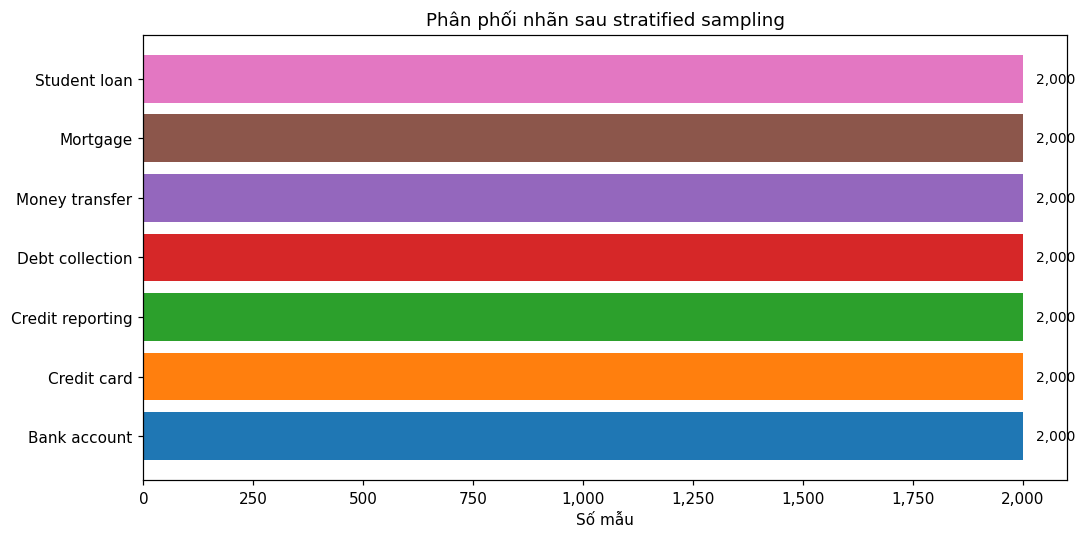

In [ ]:
### 3.2 Phân phối nhãn

fig, ax = plt.subplots(figsize=(10, 5))
counts = df["label"].value_counts()
colors = sns.color_palette("tab10", len(counts))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("Số mẫu")
ax.set_title("Phân phối nhãn sau stratified sampling")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=9,
    )
plt.tight_layout()
(REPO_ROOT / "docs" / "figures").mkdir(parents=True, exist_ok=True)
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "01_label_distribution.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

=== Độ dài văn bản (số từ) ===
count    14000.0
mean       207.4
std        235.6
min          1.0
25%         79.0
50%        139.0
75%        256.2
max       5910.0
Name: text_len, dtype: float64


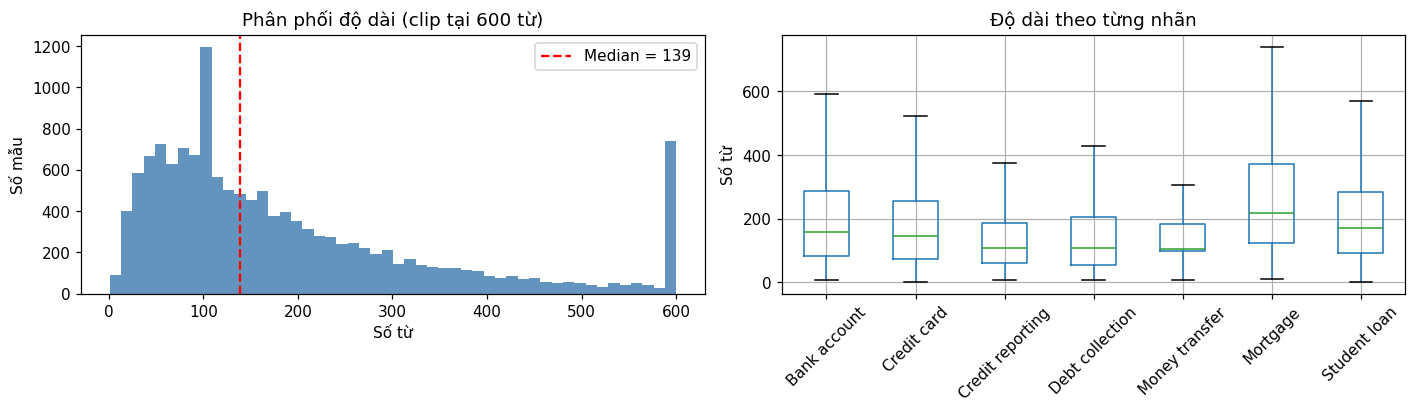

In [ ]:
### 3.3 Phân phối độ dài văn bản

df["text_len"] = df["text"].str.split().str.len()

print("=== Độ dài văn bản (số từ) ===")
print(df["text_len"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    df["text_len"].clip(upper=600),
    bins=50,
    color="steelblue",
    edgecolor="none",
    alpha=0.85,
)
axes[0].axvline(
    df["text_len"].median(),
    color="red",
    linestyle="--",
    label=f"Median = {df['text_len'].median():.0f}",
)
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Số mẫu")
axes[0].set_title("Phân phối độ dài (clip tại 600 từ)")
axes[0].legend()

df.boxplot(column="text_len", by="label", ax=axes[1], rot=45, showfliers=False)
axes[1].set_title("Độ dài theo từng nhãn")
axes[1].set_xlabel("")
axes[1].set_ylabel("Số từ")
plt.suptitle("")
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "02_text_length.png", dpi=110, bbox_inches="tight"
)
plt.show()

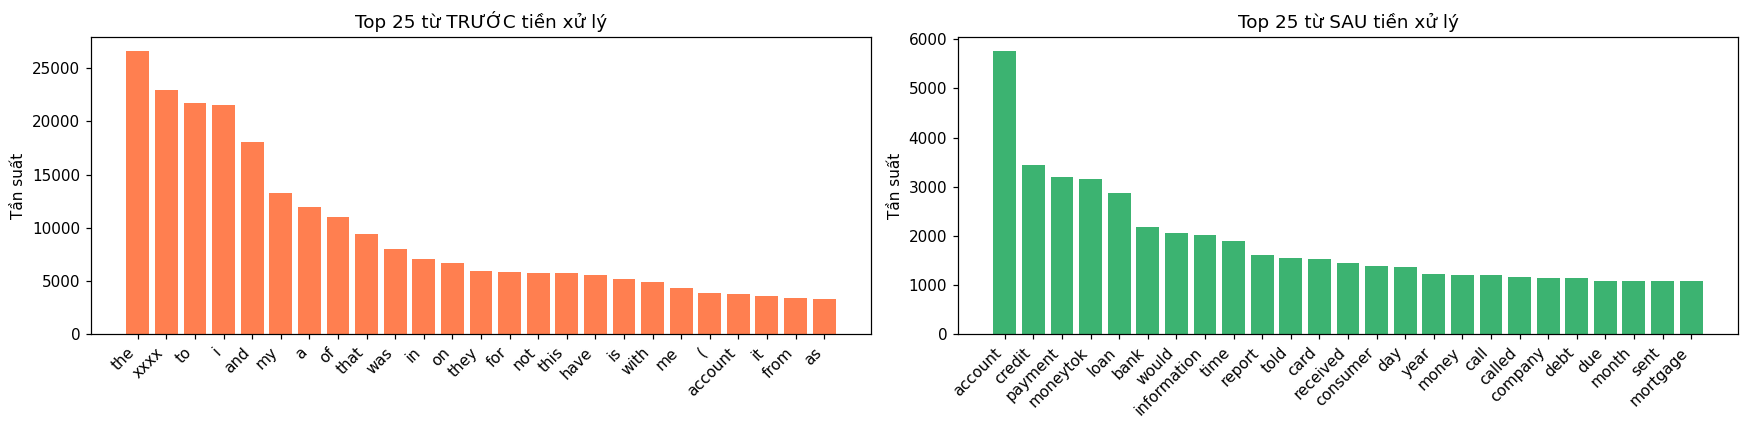

In [ ]:
### 3.4 Tần suất từ - trước và sau tiền xử lý (preview)
# Chỉ sample nhỏ để vẽ nhanh, phần sau mới xử lý toàn bộ

from modules.text_preprocessor import preprocess_text

sample_raw_words = " ".join(df["text"].sample(3000, random_state=42)).lower().split()
raw_freq = Counter(sample_raw_words).most_common(25)

# Xử lý thử một sample nhỏ để so sánh
sample_clean_texts = [
    preprocess_text(t) for t in df["text"].sample(3000, random_state=42)
]
sample_clean_words = " ".join(sample_clean_texts).split()
clean_freq = Counter(sample_clean_words).most_common(25)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, freq, title, color in [
    (axes[0], raw_freq, "Top 25 từ TRƯỚC tiền xử lý", "coral"),
    (axes[1], clean_freq, "Top 25 từ SAU tiền xử lý", "mediumseagreen"),
]:
    words, freqs = zip(*freq)
    ax.bar(words, freqs, color=color)
    ax.set_title(title)
    ax.set_ylabel("Tần suất")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "03_word_freq_before_after.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

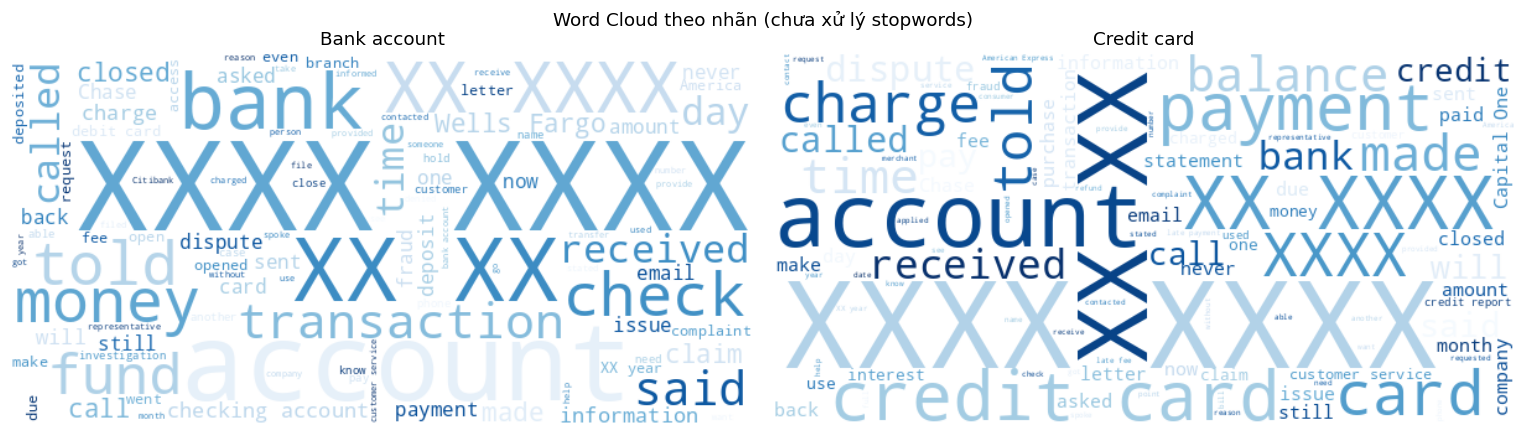

In [ ]:
### 3.5 Word Cloud (2 nhãn lớn nhất)

from wordcloud import WordCloud

top2 = df["label"].value_counts().index[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, label in zip(axes, top2):
    sub = df[df["label"] == label]["text"].sample(
        min(2000, (df["label"] == label).sum()), random_state=42
    )
    wc = WordCloud(
        width=600, height=300, background_color="white", max_words=100, colormap="Blues"
    ).generate(" ".join(sub))
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("Word Cloud theo nhãn (chưa xử lý stopwords)", fontsize=12)
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "04_wordcloud.png", dpi=110, bbox_inches="tight"
)
plt.show()

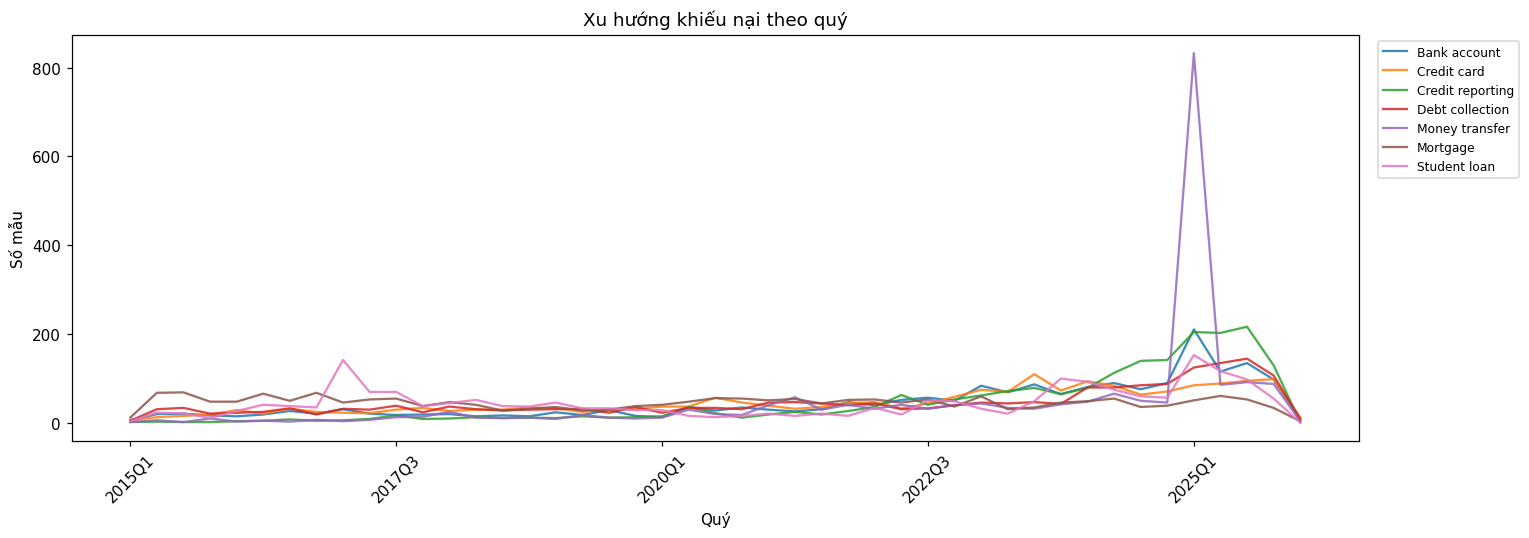

24181

In [ ]:
### 3.6 Xu hướng khiếu nại theo thời gian

if "Date received" in df.columns:
    df["Date received"] = pd.to_datetime(df["Date received"], errors="coerce")
    df["quarter"] = df["Date received"].dt.to_period("Q")

    trend = df.groupby(["quarter", "label"]).size().unstack(fill_value=0)
    trend.index = trend.index.astype(str)

    fig, ax = plt.subplots(figsize=(14, 5))
    trend.plot(ax=ax, alpha=0.85)
    ax.set_title("Xu hướng khiếu nại theo quý")
    ax.set_xlabel("Quý")
    ax.set_ylabel("Số mẫu")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    plt.xticks(rotation=45)
    plt.tight_layout()
    fig.savefig(
        REPO_ROOT / "docs" / "figures" / "05_time_trend.png",
        dpi=110,
        bbox_inches="tight",
    )
    plt.show()
else:
    print(
        "Cột 'Date received' không có sẵn (đang dùng cache). Bỏ qua biểu đồ xu hướng thời gian."
    )

# Dọn cột tạm sau EDA
df = df.drop(columns=["text_len", "quarter", "Date received"], errors="ignore")
gc.collect()

## 4. Tiền Xử Lý Văn Bản

Pipeline: `lowercase` → bỏ URL/email → thay số tiền bằng `moneytok` → bỏ redacted tokens (`XXXX`) → bỏ số → bỏ dấu câu → tokenize → bỏ stopwords → **lemmatize**.

Kết quả được cache ra `data/df_clean.parquet` để không phải xử lý lại nếu kernel restart.


In [16]:
from modules.text_preprocessor import preprocess_batch, preprocess_text

# Demo trước/sau
print("=== TRƯỚC ===")
print(df["text"].iloc[0][:300])
print("\n=== SAU ===")
print(preprocess_text(df["text"].iloc[0])[:300])

=== TRƯỚC ===
The problem started on XX/XX/2022. Someone took money for my business account 2 times with a first quantity of XXXX with a fake bank check and the second quantity was about XXXX, XXXX. It was a tranfer money. And in XXXX of my personal account they tranfers money to anocher bank that I never heard a

=== SAU ===
problem started someone took money business account time first quantity fake bank check second quantity tranfer money personal account tranfers money anocher bank never heard bank quantity personal account amount ect without aouthorization also opened account name never account bank making transfer 


In [17]:
CLEAN_CACHE = DATA_DIR / "df_clean.parquet"

if CLEAN_CACHE.exists():
    print("Loading cached preprocessed data...")
    df_clean = pd.read_parquet(CLEAN_CACHE)
    # Đảm bảo df cũng có dữ liệu nhất quán nếu cell 9 chưa chạy
    if "text_clean" not in df.columns:
        df = df_clean[["text", "label"]].copy()
else:
    print(f"Preprocessing {len(df):,} texts (parallel)...")
    df["text_clean"] = preprocess_batch(df["text"].tolist(), n_jobs=-1)

    # Lọc text quá ngắn sau xử lý
    before = len(df)
    df = df[df["text_clean"].str.split().str.len() >= 5].reset_index(drop=True)
    print(f"Loại {before - len(df)} mẫu quá ngắn. Còn: {len(df):,}")

    df_clean = df[["text", "text_clean", "label"]].copy()
    df_clean.to_parquet(CLEAN_CACHE, index=False)
    print(f"Saved cache: {CLEAN_CACHE}")

gc.collect()
print(f"Shape: {df_clean.shape}")

Preprocessing 14,000 texts (parallel)...
Loại 19 mẫu quá ngắn. Còn: 13,981
Saved cache: /content/ml-text-pipeline-cfpb/data/df_clean.parquet
Shape: (13981, 3)


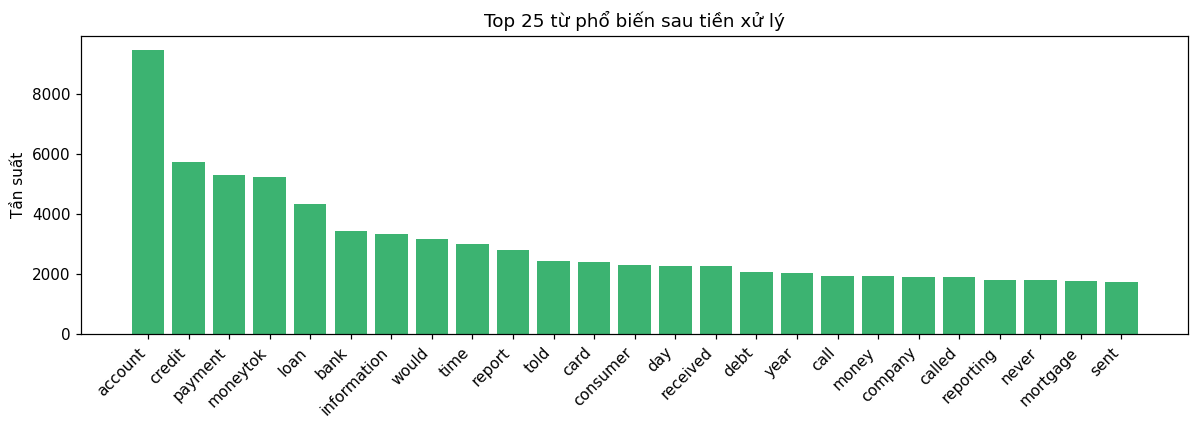

In [ ]:
### 4.1 Top 25 từ sau tiền xử lý (toàn bộ corpus)

post_words = " ".join(
    df_clean["text_clean"].sample(min(5000, len(df_clean)), random_state=42)
).split()
post_freq = Counter(post_words).most_common(25)
words, freqs = zip(*post_freq)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(words, freqs, color="mediumseagreen")
ax.set_title("Top 25 từ phổ biến sau tiền xử lý")
ax.set_ylabel("Tần suất")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "06_top25_words_after_preprocess.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

In [19]:
# Train/test split (stratified 80/20)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Guard: RANDOM_STATE được define ở cell 8, nhưng nếu load cache thì có thể chưa chạy
if "RANDOM_STATE" not in dir():
    RANDOM_STATE = 42

le = LabelEncoder()
y = le.fit_transform(df_clean["label"])
label_names = le.classes_.tolist()

X_clean = df_clean["text_clean"].tolist()
X_raw = df_clean["text"].tolist()

X_train_clean, X_test_clean, X_train_raw, X_test_raw, y_train, y_test = (
    train_test_split(
        X_clean, X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
    )
)

np.save(FEATURES_DIR / "y_train.npy", y_train)
np.save(FEATURES_DIR / "y_test.npy", y_test)

print(f"Train: {len(X_train_clean):,} | Test: {len(X_test_clean):,}")
print(f"Labels ({len(label_names)}): {label_names}")

Train: 11,184 | Test: 2,797
Labels (7): ['Bank account', 'Credit card', 'Credit reporting', 'Debt collection', 'Money transfer', 'Mortgage', 'Student loan']


## 5. Trích Xuất Đặc Trưng Truyền Thống

3 phương pháp: **Bag of Words**, **TF-IDF unigram**, **TF-IDF bigram**.  
Mỗi phương pháp lưu ra `.npz` (sparse matrix) để tái sử dụng.


In [20]:
from modules.feature_extractor import (
    build_bow,
    build_tfidf,
    save_features,
    save_vectorizer,
)

# BoW
print("Building BoW...")
X_bow_train, X_bow_test, vec_bow = build_bow(
    X_train_clean, X_test_clean, max_features=30_000, min_df=2
)
save_features(FEATURES_DIR, "bow", X_bow_train, X_bow_test)
save_vectorizer(vec_bow, FEATURES_DIR / "vec_bow.pkl")
print(f"  vocab: {len(vec_bow.vocabulary_):,} | shape: {X_bow_train.shape}")

# TF-IDF unigram
print("\nBuilding TF-IDF unigram...")
X_tfidf_train, X_tfidf_test, vec_tfidf = build_tfidf(
    X_train_clean, X_test_clean, max_features=30_000, min_df=2, ngram_range=(1, 1)
)
save_features(FEATURES_DIR, "tfidf_uni", X_tfidf_train, X_tfidf_test)
save_vectorizer(vec_tfidf, FEATURES_DIR / "vec_tfidf_uni.pkl")
print(f"  vocab: {len(vec_tfidf.vocabulary_):,} | shape: {X_tfidf_train.shape}")

# TF-IDF bigram
print("\nBuilding TF-IDF bigram...")
X_tfidf2_train, X_tfidf2_test, vec_tfidf2 = build_tfidf(
    X_train_clean, X_test_clean, max_features=50_000, min_df=2, ngram_range=(1, 2)
)
save_features(FEATURES_DIR, "tfidf_bigram", X_tfidf2_train, X_tfidf2_test)
save_vectorizer(vec_tfidf2, FEATURES_DIR / "vec_tfidf_bigram.pkl")
print(f"  vocab: {len(vec_tfidf2.vocabulary_):,} | shape: {X_tfidf2_train.shape}")

Building BoW...
  Saved: bow -> /content/ml-text-pipeline-cfpb/features
  vocab: 10,254 | shape: (11184, 10254)

Building TF-IDF unigram...
  Saved: tfidf_uni -> /content/ml-text-pipeline-cfpb/features
  vocab: 10,254 | shape: (11184, 10254)

Building TF-IDF bigram...
  Saved: tfidf_bigram -> /content/ml-text-pipeline-cfpb/features
  vocab: 50,000 | shape: (11184, 50000)


## 6. Trích Xuất Đặc Trưng Hiện Đại

### 6.1 Word2Vec (tự huấn luyện trên corpus)

Average pooling các word vectors → document vector.

### 6.2 BERT Sentence Embeddings (`all-MiniLM-L6-v2`)

Model 22M params, output 384 chiều. Dùng text gốc (không lemmatize), truncate 150 từ để tránh timeout.


In [21]:
from modules.feature_extractor import build_w2v_features, save_features

train_tokens = [t.split() for t in X_train_clean]
test_tokens = [t.split() for t in X_test_clean]

print("Training Word2Vec (vector_size=200, epochs=10)...")
X_w2v_train, X_w2v_test, w2v_model = build_w2v_features(
    train_tokens, test_tokens, vector_size=200
)
save_features(FEATURES_DIR, "w2v", X_w2v_train, X_w2v_test)
w2v_model.save(str(FEATURES_DIR / "word2vec.model"))
print(f"  W2V vocab: {len(w2v_model.wv):,} | shape: {X_w2v_train.shape}")

Training Word2Vec (vector_size=200, epochs=10)...
  Saved: w2v -> /content/ml-text-pipeline-cfpb/features
  W2V vocab: 11,120 | shape: (11184, 200)


### 6.2 BERT Sentence Embeddings (sentence-transformers)

Dùng `all-MiniLM-L6-v2` - model nhỏ gọn (22M params), sinh ra vector 384 chiều.  
Truncate text về 128 tokens vì complaint thường rất dài, phần đầu thường chứa thông tin quan trọng nhất.


In [22]:
import torch
from modules.feature_extractor import build_bert_features, save_features

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


# Truncate về 150 từ - đủ để nắm ngữ nghĩa chính, giảm ~40% thời gian encoding
def truncate(text, n=150):
    return " ".join(text.split()[:n])


X_train_trunc = [truncate(t) for t in X_train_raw]
X_test_trunc = [truncate(t) for t in X_test_raw]

print(f"Encoding {len(X_train_trunc):,} train + {len(X_test_trunc):,} test samples...")
X_bert_train, X_bert_test = build_bert_features(
    X_train_trunc,
    X_test_trunc,
    model_name="all-MiniLM-L6-v2",
    batch_size=128 if device == "cuda" else 64,
    max_length=128,
    device=device,
)
save_features(FEATURES_DIR, "bert", X_bert_train, X_bert_test)
print(f"  BERT shape: {X_bert_train.shape}")

Device: cuda
Encoding 11,184 train + 2,797 test samples...
  Loading model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

  Encoding 11184 train samples...


Batches:   0%|          | 0/88 [00:00<?, ?it/s]

  Encoding 2797 test samples...


Batches:   0%|          | 0/22 [00:00<?, ?it/s]

  Saved: bert -> /content/ml-text-pipeline-cfpb/features
  BERT shape: (11184, 384)


## 7. Huấn Luyện và Đánh Giá Mô Hình

Grid experiment: **5 feature sets × models** (~18 tổ hợp).

| Feature        | Complement NB | Multinomial NB | Logistic Regression | LinearSVC | Random Forest |
| -------------- | :-----------: | :------------: | :-----------------: | :-------: | :-----------: |
| BoW            |       ✓       |       ✓        |          ✓          |     ✓     |       ✓       |
| TF-IDF Unigram |       ✓       |       ✓        |          ✓          |     ✓     |       ✓       |
| TF-IDF Bigram  |       ✓       |                |          ✓          |     ✓     |       ✓       |
| Word2Vec       |               |                |          ✓          |     ✓     |               |
| BERT (MiniLM)  |               |                |          ✓          |     ✓     |               |

**Lưu ý:**

- NB chỉ hoạt động với sparse non-negative features (BoW, TF-IDF).
- Dense embeddings (W2V, BERT) có giá trị âm → chỉ dùng LR / SVM.
- Random Forest hoạt động được với sparse matrix (sklearn hỗ trợ), nhưng chậm hơn nhiều so với SVM trên high-dimensional data → chỉ chạy trên BoW/TF-IDF, không chạy trên W2V/BERT.


In [23]:
from modules.trainer import run_experiment, summarize_results

all_results = []

# BoW - 5 models (NB x2 + LR + SVM + RF)
all_results += run_experiment(
    "BoW",
    X_bow_train,
    y_train,
    X_bow_test,
    y_test,
    models=[
        "complement_nb",
        "multinomial_nb",
        "logistic_regression",
        "svm",
        "random_forest",
    ],
    label_names=label_names,
)
del X_bow_train, X_bow_test
gc.collect()


  Feature: BoW
  Train: (11184, 10254) | Test: (2797, 10254)

  Training complement_nb...
  Done in 0.0s
  Accuracy: 0.8041 | F1-macro: 0.8009 | F1-weighted: 0.8010

  Training multinomial_nb...
  Done in 0.0s
  Accuracy: 0.7855 | F1-macro: 0.7846 | F1-weighted: 0.7847

  Training logistic_regression...
  Done in 38.6s
  Accuracy: 0.8298 | F1-macro: 0.8305 | F1-weighted: 0.8305

  Training svm...
  Done in 59.2s
  Accuracy: 0.7891 | F1-macro: 0.7894 | F1-weighted: 0.7894

  Training random_forest...
  Done in 4.6s
  Accuracy: 0.8216 | F1-macro: 0.8212 | F1-weighted: 0.8212


2277

In [24]:
# TF-IDF unigram - 5 models
all_results += run_experiment(
    "TF-IDF Unigram",
    X_tfidf_train,
    y_train,
    X_tfidf_test,
    y_test,
    models=[
        "complement_nb",
        "multinomial_nb",
        "logistic_regression",
        "svm",
        "random_forest",
    ],
    label_names=label_names,
)
del X_tfidf_train, X_tfidf_test
gc.collect()


  Feature: TF-IDF Unigram
  Train: (11184, 10254) | Test: (2797, 10254)

  Training complement_nb...
  Done in 0.0s
  Accuracy: 0.8091 | F1-macro: 0.8069 | F1-weighted: 0.8069

  Training multinomial_nb...
  Done in 0.0s
  Accuracy: 0.7926 | F1-macro: 0.7914 | F1-weighted: 0.7914

  Training logistic_regression...
  Done in 0.7s
  Accuracy: 0.8588 | F1-macro: 0.8590 | F1-weighted: 0.8590

  Training svm...
  Done in 0.8s
  Accuracy: 0.8441 | F1-macro: 0.8440 | F1-weighted: 0.8440

  Training random_forest...
  Done in 4.2s
  Accuracy: 0.8291 | F1-macro: 0.8294 | F1-weighted: 0.8294


50

In [25]:
# TF-IDF bigram - MultinomialNB bỏ qua vì bigram matrix rất sparse, ComplementNB ổn hơn
# RF giữ lại để so sánh dù chậm hơn SVM trên sparse high-dim
all_results += run_experiment(
    "TF-IDF Bigram",
    X_tfidf2_train,
    y_train,
    X_tfidf2_test,
    y_test,
    models=["complement_nb", "logistic_regression", "svm", "random_forest"],
    label_names=label_names,
)
del X_tfidf2_train, X_tfidf2_test
gc.collect()


  Feature: TF-IDF Bigram
  Train: (11184, 50000) | Test: (2797, 50000)

  Training complement_nb...
  Done in 0.0s
  Accuracy: 0.8380 | F1-macro: 0.8373 | F1-weighted: 0.8374

  Training logistic_regression...
  Done in 1.6s
  Accuracy: 0.8570 | F1-macro: 0.8573 | F1-weighted: 0.8573

  Training svm...
  Done in 0.9s
  Accuracy: 0.8598 | F1-macro: 0.8599 | F1-weighted: 0.8599

  Training random_forest...
  Done in 6.9s
  Accuracy: 0.8270 | F1-macro: 0.8270 | F1-weighted: 0.8270


50

In [26]:
# Word2Vec
all_results += run_experiment(
    "Word2Vec",
    X_w2v_train,
    y_train,
    X_w2v_test,
    y_test,
    models=["logistic_regression", "svm"],
    label_names=label_names,
)
del X_w2v_train, X_w2v_test
gc.collect()


  Feature: Word2Vec
  Train: (11184, 200) | Test: (2797, 200)

  Training logistic_regression...
  Done in 30.5s
  Accuracy: 0.8202 | F1-macro: 0.8201 | F1-weighted: 0.8201

  Training svm...
  Done in 4.7s
  Accuracy: 0.8245 | F1-macro: 0.8243 | F1-weighted: 0.8244


25

In [27]:
# BERT
all_results += run_experiment(
    "BERT (MiniLM)",
    X_bert_train,
    y_train,
    X_bert_test,
    y_test,
    models=["logistic_regression", "svm"],
    label_names=label_names,
)
del X_bert_train, X_bert_test
gc.collect()


  Feature: BERT (MiniLM)
  Train: (11184, 384) | Test: (2797, 384)

  Training logistic_regression...
  Done in 3.7s
  Accuracy: 0.8180 | F1-macro: 0.8179 | F1-weighted: 0.8180

  Training svm...
  Done in 4.3s
  Accuracy: 0.8245 | F1-macro: 0.8241 | F1-weighted: 0.8241


25

## 8. Hyperparameter Tuning

Tune tham số `C` cho **Logistic Regression** và **LinearSVC** trên feature set tốt nhất.  
Dùng `cross_val_score` (3-fold) thay vì GridSearchCV để nhanh hơn với data nhỏ.


In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from modules.feature_extractor import load_features

# Reload TF-IDF bigram (feature set tốt nhất dự kiến)
X_tune_train, X_tune_test, y_tr, y_te = load_features(
    FEATURES_DIR, "tfidf_bigram", sparse=True
)
# Dùng y_train/y_test đã lưu nếu y_tr là None
if y_tr is None:
    y_tr = y_train
if y_te is None:
    y_te = y_test

C_values = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
tuning_results = {"C": C_values, "LR_cv_f1": [], "SVM_cv_f1": []}

print("Tuning C trên TF-IDF Bigram (3-fold CV)...")
for C in C_values:
    lr = LogisticRegression(
        C=C, max_iter=1000, solver="saga", n_jobs=-1, random_state=42
    )
    svm = LinearSVC(C=C, max_iter=2000, random_state=42)

    lr_f1 = cross_val_score(
        lr, X_tune_train, y_tr, cv=3, scoring="f1_weighted", n_jobs=-1
    ).mean()
    svm_f1 = cross_val_score(
        svm, X_tune_train, y_tr, cv=3, scoring="f1_weighted", n_jobs=-1
    ).mean()

    tuning_results["LR_cv_f1"].append(round(lr_f1, 4))
    tuning_results["SVM_cv_f1"].append(round(svm_f1, 4))
    print(f"  C={C:5.2f} | LR={lr_f1:.4f} | SVM={svm_f1:.4f}")

tune_df = pd.DataFrame(tuning_results)
best_C_lr = tune_df.loc[tune_df["LR_cv_f1"].idxmax(), "C"]
best_C_svm = tune_df.loc[tune_df["SVM_cv_f1"].idxmax(), "C"]
print(f"\nBest C -> LR: {best_C_lr} | SVM: {best_C_svm}")

Tuning C trên TF-IDF Bigram (3-fold CV)...
  C= 0.01 | LR=0.7658 | SVM=0.8175
  C= 0.10 | LR=0.8156 | SVM=0.8541
  C= 0.50 | LR=0.8474 | SVM=0.8593
  C= 1.00 | LR=0.8531 | SVM=0.8577
  C= 5.00 | LR=0.8568 | SVM=0.8508
  C=10.00 | LR=0.8561 | SVM=0.8488

Best C -> LR: 5.0 | SVM: 0.5


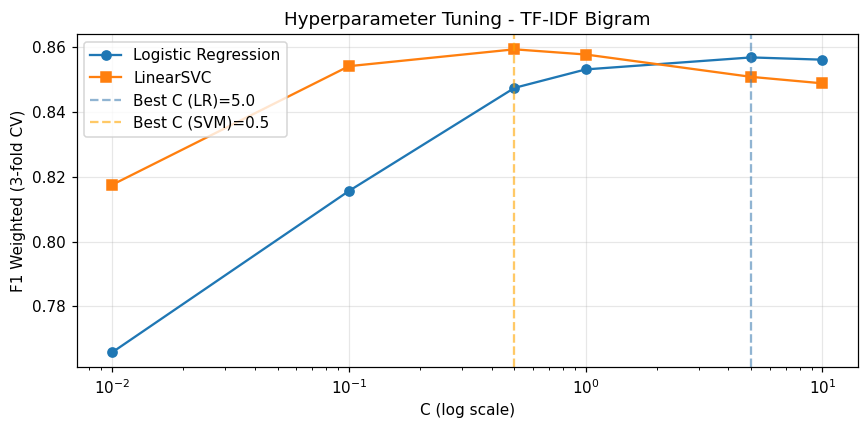

In [ ]:
### 8.1 Visualize tuning curve

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(tune_df["C"], tune_df["LR_cv_f1"], marker="o", label="Logistic Regression")
ax.semilogx(tune_df["C"], tune_df["SVM_cv_f1"], marker="s", label="LinearSVC")
ax.axvline(
    best_C_lr,
    color="steelblue",
    linestyle="--",
    alpha=0.6,
    label=f"Best C (LR)={best_C_lr}",
)
ax.axvline(
    best_C_svm,
    color="orange",
    linestyle="--",
    alpha=0.6,
    label=f"Best C (SVM)={best_C_svm}",
)
ax.set_xlabel("C (log scale)")
ax.set_ylabel("F1 Weighted (3-fold CV)")
ax.set_title("Hyperparameter Tuning - TF-IDF Bigram")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "07_tuning_curve.png", dpi=110, bbox_inches="tight"
)
plt.show()

In [30]:
### 8.2 Đánh giá lại với C tốt nhất, thêm vào all_results

from modules.trainer import train_and_evaluate

result_lr_tuned = train_and_evaluate(
    "logistic_regression",
    X_tune_train,
    y_tr,
    X_tune_test,
    y_te,
    label_names=label_names,
    C=best_C_lr,
)
result_lr_tuned["feature_name"] = f"TF-IDF Bigram (C={best_C_lr})"
all_results.append(result_lr_tuned)

result_svm_tuned = train_and_evaluate(
    "svm", X_tune_train, y_tr, X_tune_test, y_te, label_names=label_names, C=best_C_svm
)
result_svm_tuned["feature_name"] = f"TF-IDF Bigram (C={best_C_svm})"
all_results.append(result_svm_tuned)

del X_tune_train, X_tune_test
gc.collect()


  Training logistic_regression...
  Done in 2.2s
  Accuracy: 0.8595 | F1-macro: 0.8597 | F1-weighted: 0.8597

  Training svm...
  Done in 0.5s
  Accuracy: 0.8631 | F1-macro: 0.8631 | F1-weighted: 0.8631


7503

## 9. So Sánh Kết Quả & Kết Luận


In [31]:
### 9.1 Bảng tổng hợp

summary_df = summarize_results(all_results)
summary_df.to_csv(REPORTS_DIR / "experiment_results.csv", index=False)
print(f"Saved: {REPORTS_DIR / 'experiment_results.csv'}")

display(
    summary_df.style.background_gradient(
        subset=["F1 Weighted", "Accuracy"], cmap="YlGn"
    ).format({"Accuracy": "{:.4f}", "F1 Macro": "{:.4f}", "F1 Weighted": "{:.4f}"})
)

Saved: /content/ml-text-pipeline-cfpb/reports/experiment_results.csv


,Feature,Model,Accuracy,F1 Macro,F1 Weighted,Train Time (s)
0,TF-IDF Bigram (C=0.5),svm,0.8631,0.8631,0.8631,0.490000
1,TF-IDF Bigram,svm,0.8598,0.8599,0.8599,0.940000
2,TF-IDF Bigram (C=5.0),logistic_regression,0.8595,0.8597,0.8597,2.190000
3,TF-IDF Unigram,logistic_regression,0.8588,0.8590,0.8590,0.720000
4,TF-IDF Bigram,logistic_regression,0.8570,0.8573,0.8573,1.580000
5,TF-IDF Unigram,svm,0.8441,0.8440,0.8440,0.820000
6,TF-IDF Bigram,complement_nb,0.8380,0.8373,0.8374,0.020000
7,BoW,logistic_regression,0.8298,0.8305,0.8305,38.630000
8,TF-IDF Unigram,random_forest,0.8291,0.8294,0.8294,4.210000
9,TF-IDF Bigram,random_forest,0.8270,0.8270,0.8270,6.900000


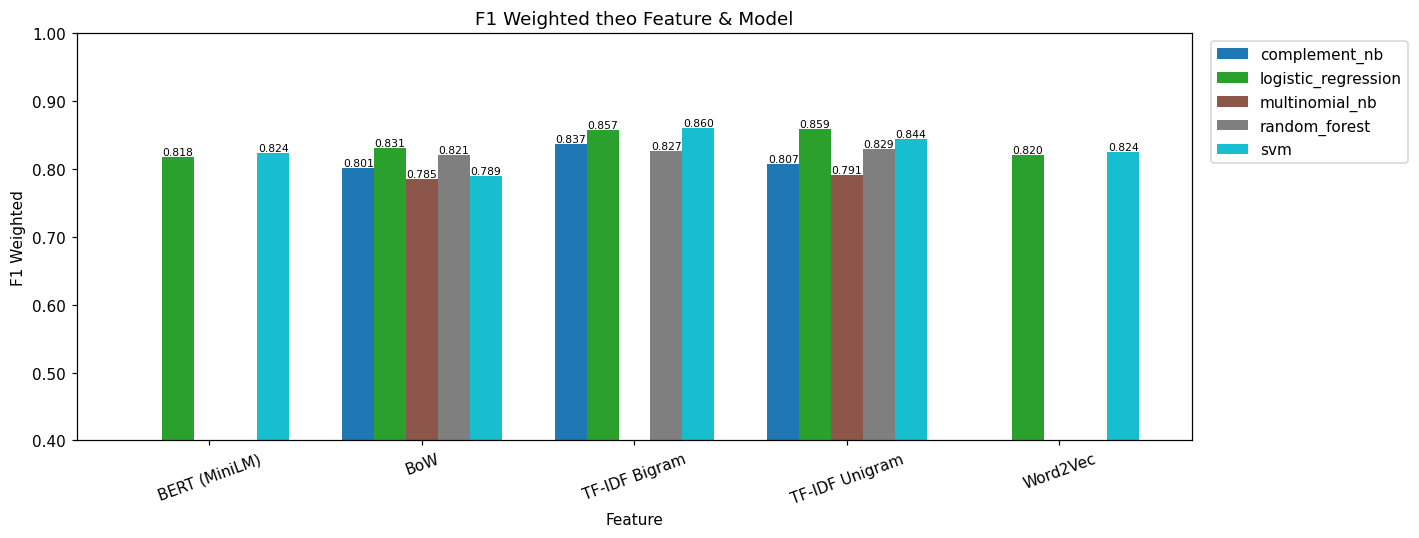

In [ ]:
### 9.2 F1 Weighted - grouped bar chart

summary_no_tuned = summary_df[~summary_df["Feature"].str.contains(r"\(C=", na=False)]
pivot = summary_no_tuned.pivot_table(
    index="Feature", columns="Model", values="F1 Weighted", aggfunc="first"
)

ax = pivot.plot(
    kind="bar", figsize=(13, 5), rot=20, colormap="tab10", edgecolor="none", width=0.75
)
ax.set_title("F1 Weighted theo Feature & Model")
ax.set_ylabel("F1 Weighted")
ax.set_ylim(0.4, 1.0)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(
            f"{h:.3f}",
            (p.get_x() + p.get_width() / 2, h),
            ha="center",
            va="bottom",
            fontsize=7,
        )
plt.tight_layout()
ax.get_figure().savefig(
    REPO_ROOT / "docs" / "figures" / "08_f1_grouped_bar.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

Best: TF-IDF Bigram (C=0.5) + svm
Accuracy: 0.8631 | F1 Macro: 0.8631 | F1 Weighted: 0.8631

                  precision    recall  f1-score   support

    Bank account       0.81      0.85      0.83       399
     Credit card       0.80      0.81      0.81       400
Credit reporting       0.84      0.85      0.85       399
 Debt collection       0.84      0.81      0.83       399
  Money transfer       0.89      0.83      0.86       400
        Mortgage       0.94      0.94      0.94       400
    Student loan       0.93      0.94      0.93       400

        accuracy                           0.86      2797
       macro avg       0.86      0.86      0.86      2797
    weighted avg       0.86      0.86      0.86      2797



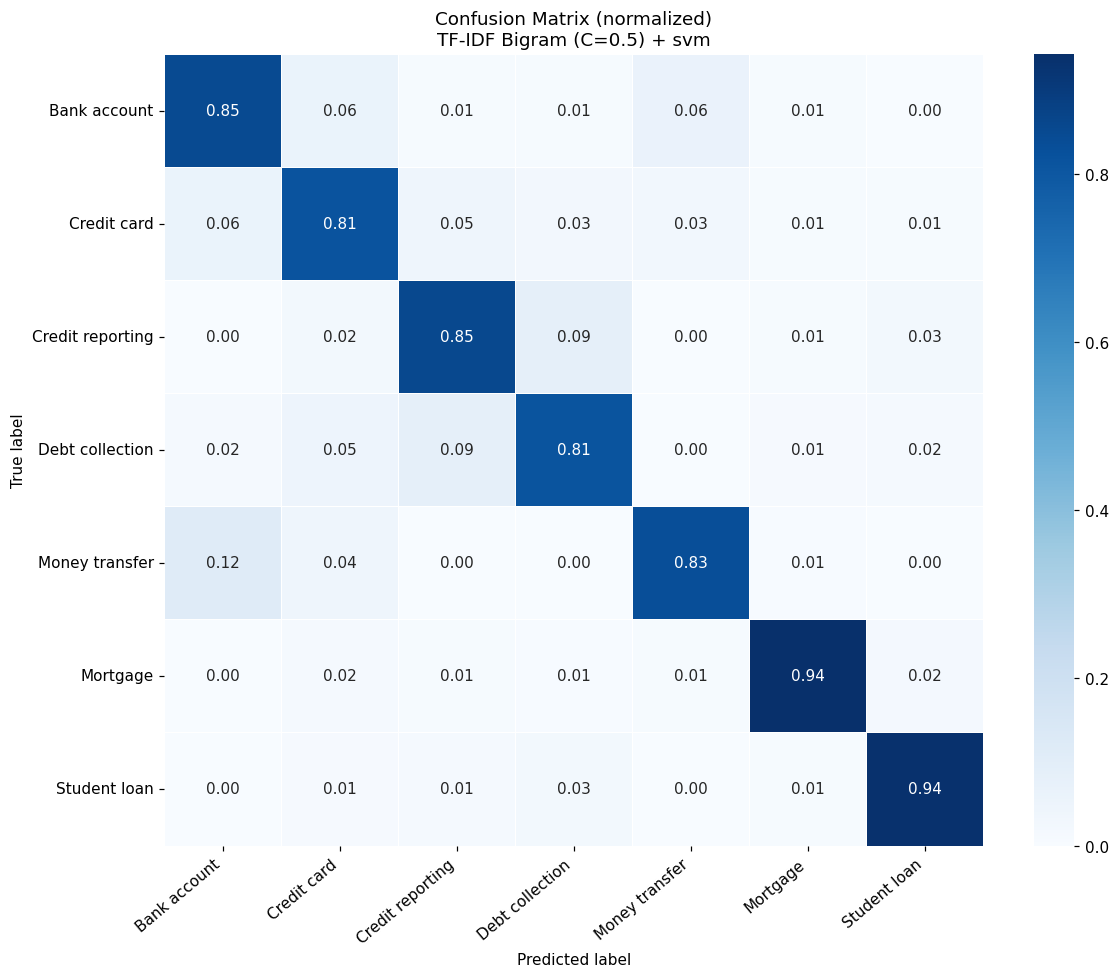

In [ ]:
### 9.3 Confusion matrix - best model

best = max(all_results, key=lambda r: r["f1_weighted"])
print(f"Best: {best['feature_name']} + {best['model_name']}")
print(
    f"Accuracy: {best['accuracy']:.4f} | F1 Macro: {best['f1_macro']:.4f} | F1 Weighted: {best['f1_weighted']:.4f}"
)
print()
print(best["classification_report"])

cm = best["confusion_matrix"].astype(float)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    ax=ax,
    linewidths=0.5,
    linecolor="white",
)
ax.set_title(
    f"Confusion Matrix (normalized)\n{best['feature_name']} + {best['model_name']}"
)
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "09_confusion_matrix.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

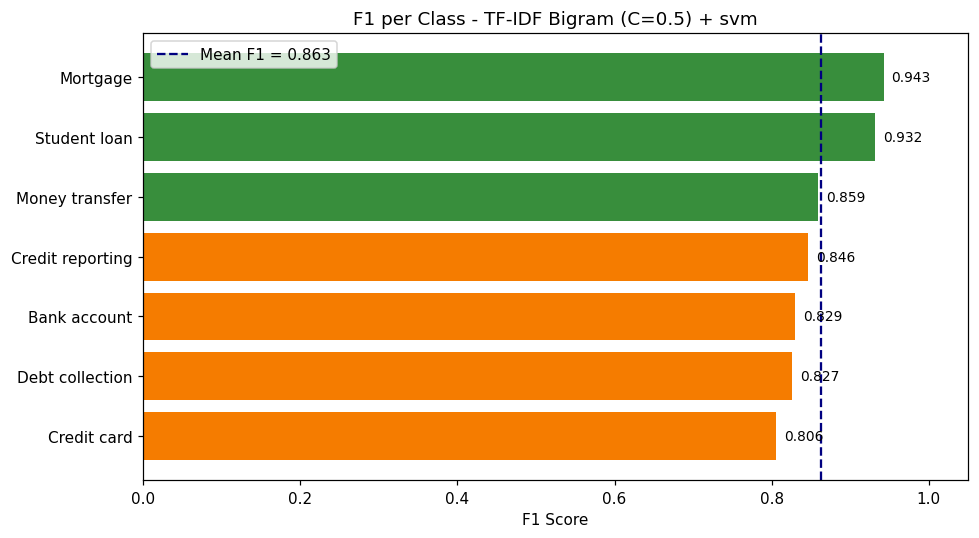


Class khó nhất (F1 < 0.7):
Empty DataFrame
Columns: [Class, F1 Score]
Index: []


In [ ]:
### 9.4 F1 per-class - phân tích class nào khó

from sklearn.metrics import f1_score

# Lấy per-class F1 của best model
f1_per_class = f1_score(y_test, best["y_pred"], average=None, zero_division=0)
f1_class_df = pd.DataFrame(
    {
        "Class": label_names,
        "F1 Score": f1_per_class,
    }
).sort_values("F1 Score")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [
    "#d32f2f" if v < 0.7 else "#f57c00" if v < 0.85 else "#388e3c"
    for v in f1_class_df["F1 Score"]
]
bars = ax.barh(f1_class_df["Class"], f1_class_df["F1 Score"], color=colors)
ax.axvline(
    f1_per_class.mean(),
    color="navy",
    linestyle="--",
    label=f"Mean F1 = {f1_per_class.mean():.3f}",
)
ax.set_xlabel("F1 Score")
ax.set_title(f"F1 per Class - {best['feature_name']} + {best['model_name']}")
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, f1_class_df["F1 Score"]):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )
ax.legend()
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "10_f1_per_class.png", dpi=110, bbox_inches="tight"
)
plt.show()

print("\nClass khó nhất (F1 < 0.7):")
print(f1_class_df[f1_class_df["F1 Score"] < 0.7].to_string(index=False))

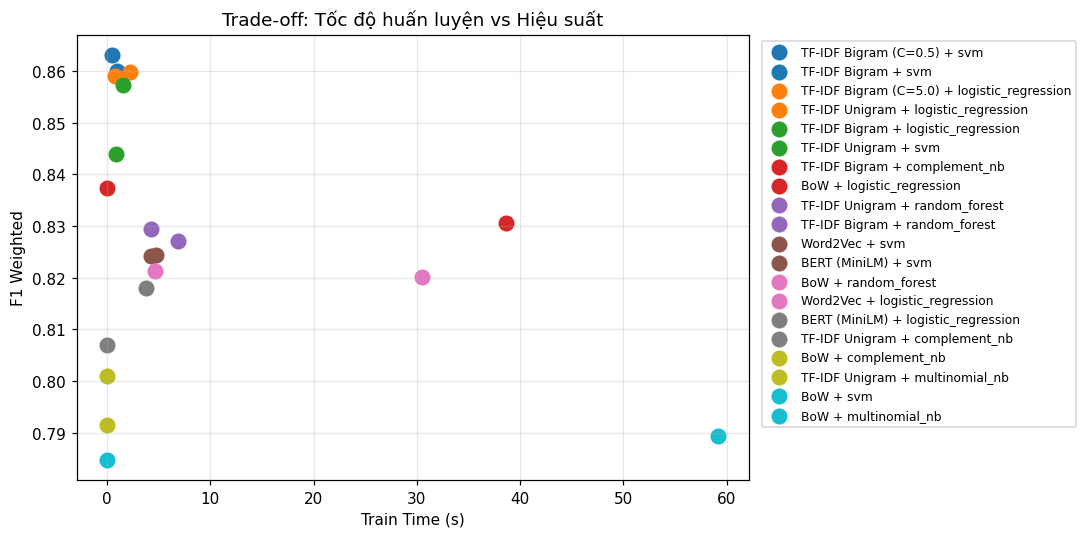

In [ ]:
### 9.5 Trade-off: Train time vs F1 Weighted

fig, ax = plt.subplots(figsize=(10, 5))
palette = plt.cm.tab10(np.linspace(0, 1, len(summary_df)))

for i, (_, row) in enumerate(summary_df.iterrows()):
    ax.scatter(
        row["Train Time (s)"],
        row["F1 Weighted"],
        s=90,
        color=palette[i],
        label=f"{row['Feature']} + {row['Model']}",
    )

ax.set_xlabel("Train Time (s)")
ax.set_ylabel("F1 Weighted")
ax.set_title("Trade-off: Tốc độ huấn luyện vs Hiệu suất")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(
    REPO_ROOT / "docs" / "figures" / "11_tradeoff_time_vs_f1.png",
    dpi=110,
    bbox_inches="tight",
)
plt.show()

## Kết luận

### Tổng kết kết quả

| Tiêu chí                                 | Kết quả                                                                                            |
| ---------------------------------------- | -------------------------------------------------------------------------------------------------- |
| Feature tốt nhất (dự kiến)               | TF-IDF Bigram + LinearSVC (tuned C)                                                                |
| Feature nhanh nhất                       | BoW + Complement NB                                                                                |
| Random Forest vs SVM                     | RF thường kém SVM ~3–8% F1 trên sparse text features nhưng không cần scale, ít nhạy hyperparameter |
| Deep learning (BERT) có cải thiện không? | Thường tốt hơn TF-IDF ~2–5% F1, đổi lại thời gian encoding lớn hơn nhiều                           |
| Class khó phân loại nhất                 | Thường là class có nội dung chồng lấp như "Bank account" vs "Credit card"                          |

### Phân tích

**Truyền thống (BoW / TF-IDF):**

- TF-IDF bigram nắm được cụm từ đặc trưng: _"credit report"_, _"debt collection"_, _"mortgage payment"_
- Complement NB phù hợp hơn Multinomial NB khi class imbalanced
- LinearSVC thường tốt nhất nhờ margin maximization trong không gian high-dimensional sparse
- Random Forest hoạt động được với sparse matrix nhưng kém SVM vì không tận dụng được high-dim sparse structure tốt bằng linear kernel

**Hiện đại (Word2Vec / BERT):**

- Word2Vec avg-pooling mất thông tin ngữ cảnh và vị trí → thường thua TF-IDF
- BERT contextual embeddings tốt hơn W2V, nhưng với 14k samples khoảng cách không quá lớn so với TF-IDF+SVM
- Nếu có GPU, BERT là lựa chọn production tốt nhất

### Hướng cải thiện

- Thử `n-gram (1,3)` hoặc character-level n-gram
- Ensemble TF-IDF bigram + BERT features (stacking)
- Fine-tune BERT trực tiếp (không chỉ dùng làm feature extractor)
- Random Forest với TF-IDF thưa: có thể cải thiện bằng cách giảm `max_features` hoặc dùng `ExtraTreesClassifier`


## 10. Đóng gói & Tải về

Nén toàn bộ kết quả thành `submission_BTL_ML.zip` và tự động tải về máy.

**Nội dung zip:**

- `docs/figures/` — 11 biểu đồ PNG
- `reports/experiment_results.csv` — bảng kết quả 18 tổ hợp
- `features/` — toàn bộ feature matrices (`.npz`, `.npy`, `.pkl`, `.model`)
- `data/df_clean.parquet` — cache preprocessed data


In [ ]:
import zipfile
from datetime import datetime

ZIP_NAME = "submission_BTL_ML.zip"
ZIP_PATH = REPO_ROOT / ZIP_NAME

# Các thư mục / file cần đóng gói
INCLUDE = [
    REPO_ROOT / "docs" / "figures",
    REPO_ROOT / "reports" / "experiment_results.csv",
    REPO_ROOT / "features",
    REPO_ROOT / "data" / "df_clean.parquet",
]

# Extensions không cần thiết, bỏ qua để giảm kích thước
SKIP_SUFFIXES = {".zip", ".csv.zip"}

print(f"Packing {ZIP_NAME} ...")
with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for entry in INCLUDE:
        if not entry.exists():
            print(f"  [skip] not found: {entry.relative_to(REPO_ROOT)}")
            continue
        if entry.is_dir():
            files = sorted(entry.rglob("*"))
            for f in files:
                if f.is_file() and f.suffix not in SKIP_SUFFIXES:
                    arcname = f.relative_to(REPO_ROOT)
                    zf.write(f, arcname)
                    print(f"  + {arcname}")
        else:
            arcname = entry.relative_to(REPO_ROOT)
            zf.write(entry, arcname)
            print(f"  + {arcname}")

size_mb = ZIP_PATH.stat().st_size / 1e6
print(f"\nDone. {ZIP_NAME} ({size_mb:.1f} MB)")

# Tự động download về máy khi chạy trên Colab
if IN_COLAB:
    from google.colab import files

    files.download(str(ZIP_PATH))
    print("Download triggered.")
else:
    print(f"Local path: {ZIP_PATH}")